Transfer Function W(s):
<TransferFunction>: sys[36]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        3.183e-10 s^3 + 3.183e-07 s^2
  -----------------------------------------
  1e-16 s^4 + 3.979e-11 s^3 + 3.979e-08 s^2


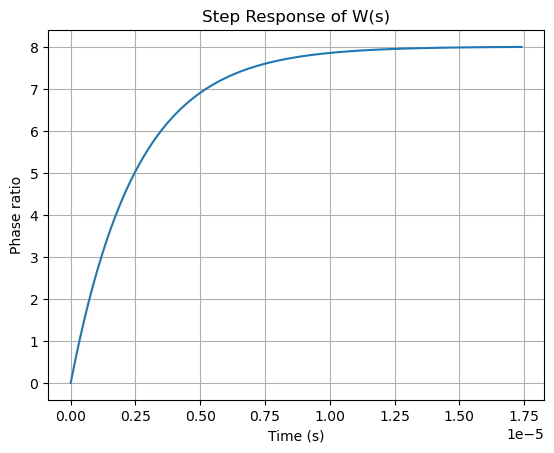

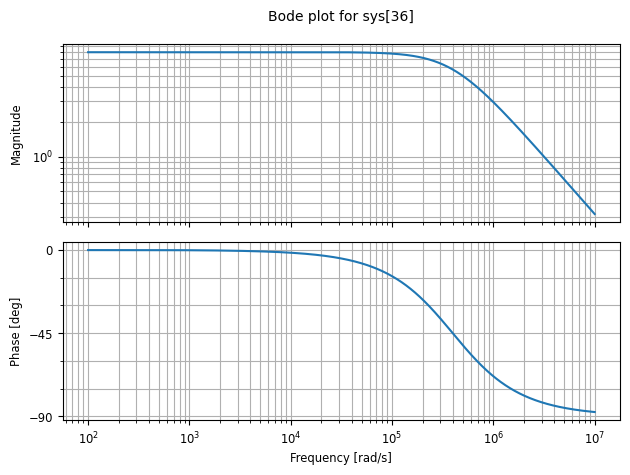

In [2]:
# PLL phase based model
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
# PLL design parameter
# currently parameter T.B.D
Ibias = 10e-6 #charg pump bias current[A]
Kvco = 10e6 #VCO volt to Frequency covnersion coefficient
N = 8 # Devider Reciprocal
R1 = 100e3 # Loop filter R1 resistance [OHM]
C1 = 10e-9 # Loop filter C1 capacitance [F]

# Define transfer function of PLL
# Define the Laplace variable 's'
s = ctrl.TransferFunction.s

# Transfer function:
#         Ibias                  Kvco  
# G(s) = ------- * (R1+1/C1s) * -------
#          π                     s
# H(s) = 1 / N
#
# Feeback loop:
#              G(s)
# W(s) = -----------------
#          1 + G(s) H(s)
G = (Ibias / np.pi) * (R1 + 1/(C1*s)) * Kvco/s
H = 1 / N
W = G / (1 + G * H) 

# Display the transfer function
print("Transfer Function W(s):")
print(W)

time, response = ctrl.step_response(W)
plt.plot(time, response)
plt.title("Step Response of W(s)")
plt.xlabel("Time (s)")
plt.ylabel("Phase ratio")
plt.grid(True)
plt.show()

ctrl.bode_plot(W)
plt.show()